# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)


# Carregamento dos Dados

In [2]:
df = pd.read_csv("../data/processed/steam_cleaned.csv", parse_dates=["release_date"])

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19371 entries, 0 to 19370
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appid             19371 non-null  int64         
 1   name              19371 non-null  object        
 2   release_date      19371 non-null  datetime64[ns]
 3   english           19371 non-null  int64         
 4   developer         19370 non-null  object        
 5   publisher         19361 non-null  object        
 6   platforms         19371 non-null  object        
 7   required_age      19371 non-null  int64         
 8   categories        19371 non-null  object        
 9   genres            19371 non-null  object        
 10  steamspy_tags     19371 non-null  object        
 11  achievements      19371 non-null  int64         
 12  positive_ratings  19371 non-null  int64         
 13  negative_ratings  19371 non-null  int64         
 14  average_playtime  1937

# Estatísticas Descritivas

In [3]:

df.describe().T

,count,mean,min,25%,50%,75%,max,std
appid,19371.0,552988.163182,10.0,365175.0,541270.0,747325.0,1065650.0,247573.089763
release_date,19371,2016-10-04 12:44:20.554437120,1997-06-30 00:00:00,2015-11-03 00:00:00,2017-04-18 00:00:00,2018-04-23 00:00:00,2019-05-01 00:00:00,NaN
english,19371.0,0.984255,0.0,1.0,1.0,1.0,1.0,0.124491
required_age,19371.0,0.448093,0.0,0.0,0.0,0.0,18.0,2.708984
achievements,19371.0,40.90367,0.0,0.0,10.0,26.0,5394.0,309.279545
positive_ratings,19371.0,1367.101905,0.0,10.0,39.0,212.0,2644404.0,22434.76612
negative_ratings,19371.0,287.514067,0.0,3.0,14.0,66.0,487076.0,5063.066223
average_playtime,19371.0,195.482887,0.0,0.0,0.0,14.0,190625.0,2137.02061
median_playtime,19371.0,189.452068,0.0,0.0,0.0,15.0,190625.0,2764.461225
price,19371.0,6.787099,0.0,1.99,4.79,8.99,421.99,8.511556


# Desenvolvedores e Publicadoras

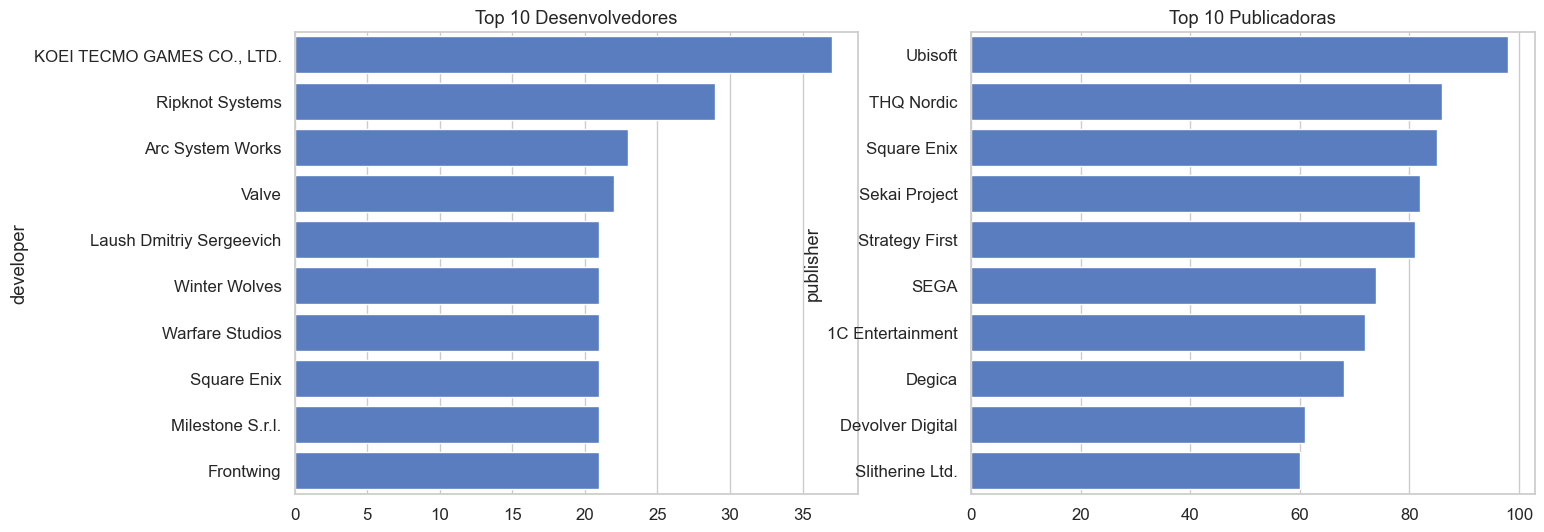

In [4]:
top_devs = df["developer"].value_counts().head(10)
top_pubs = df["publisher"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(y=top_devs.index, x=top_devs.values, ax=axes[0])
axes[0].set_title("Top 10 Desenvolvedores")

sns.barplot(y=top_pubs.index, x=top_pubs.values, ax=axes[1])
axes[1].set_title("Top 10 Publicadoras")
plt.show()

# Análise de Gêneros, Categorias e Tags

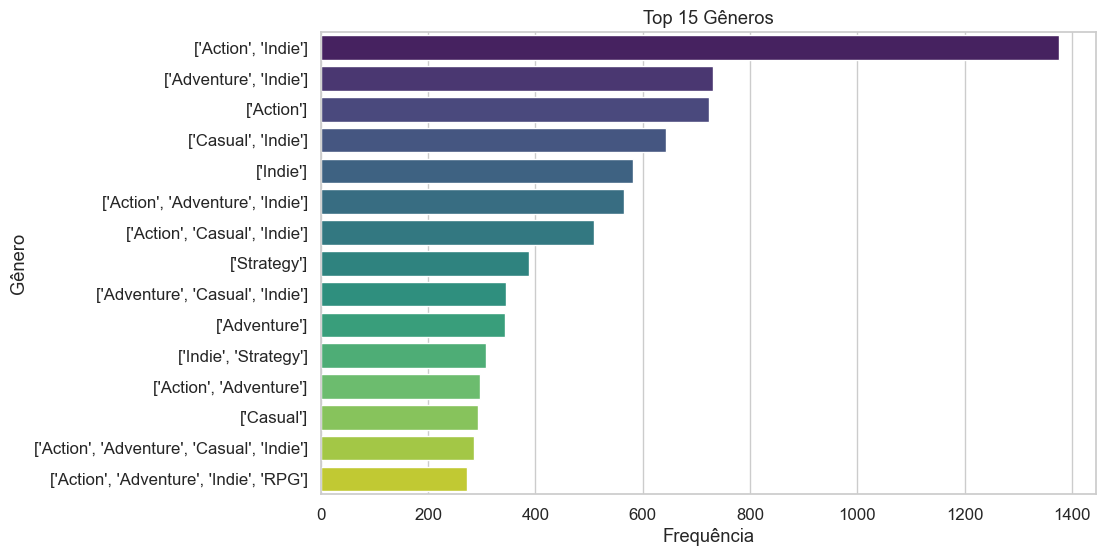

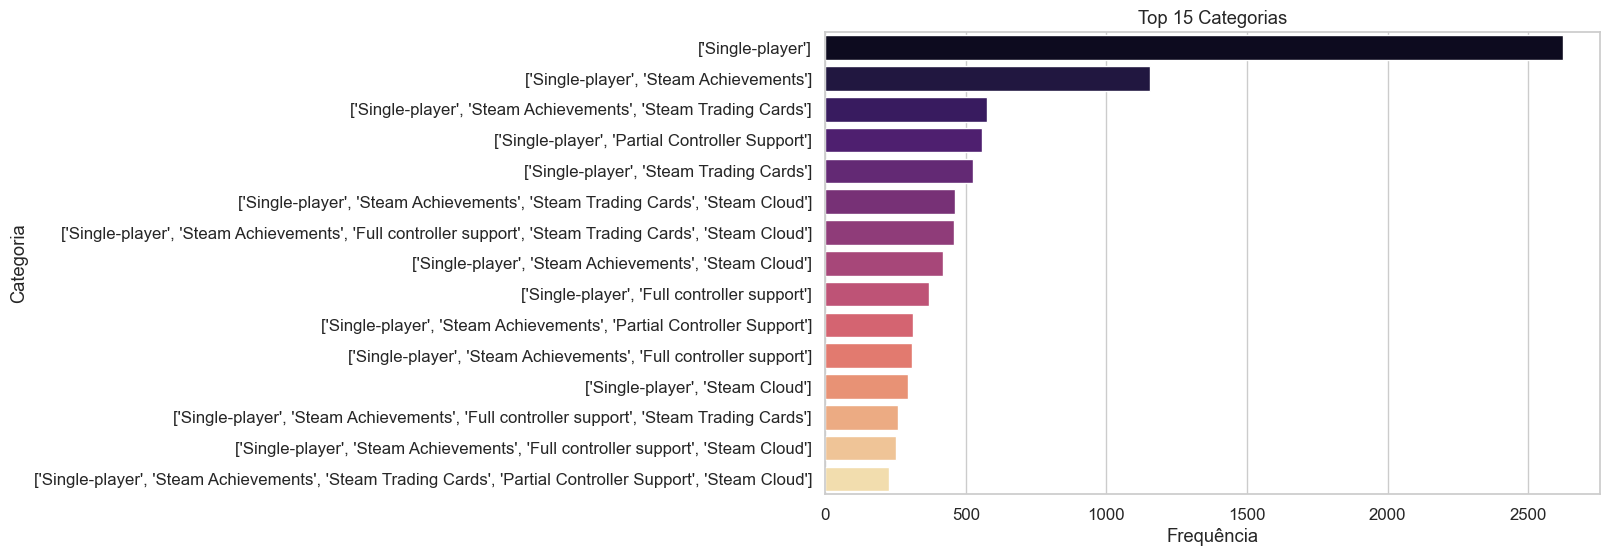

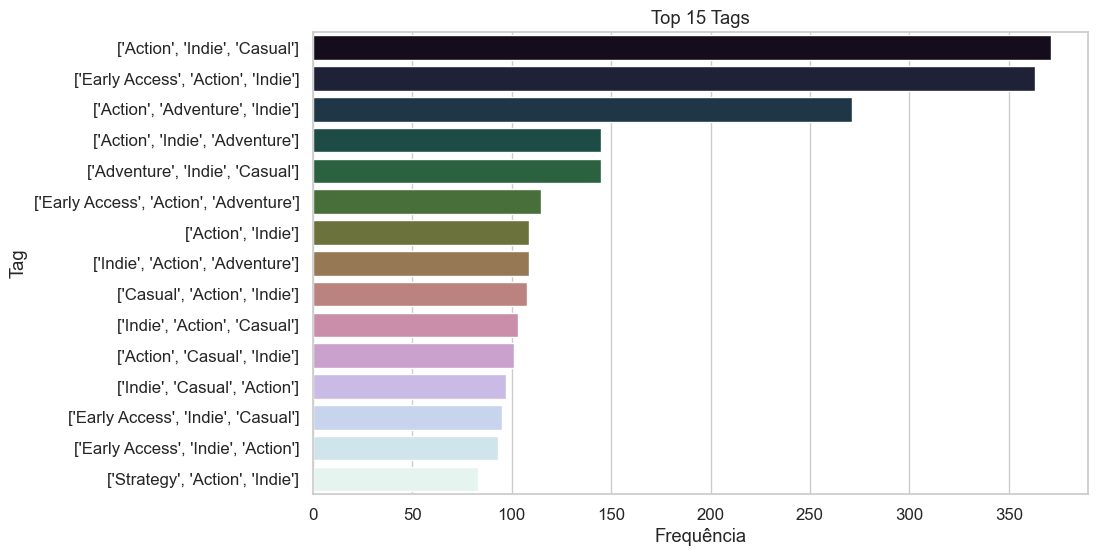

In [5]:
def contar_valores(coluna):
    lista = df[coluna].dropna().astype(str).str.split(";").sum()
    return Counter(lista).most_common(15)

top_genres = contar_valores("genres")
df_genres = pd.DataFrame(top_genres, columns=["Gênero", "Frequência"])

sns.barplot(y="Gênero", x="Frequência", data=df_genres, palette="viridis", hue="Gênero", dodge=False)
plt.title("Top 15 Gêneros")
plt.show()


top_categories = contar_valores("categories")
df_categories = pd.DataFrame(top_categories, columns=["Categoria", "Frequência"])

sns.barplot(y="Categoria", x="Frequência", data=df_categories, palette="magma", hue="Categoria", dodge=False)
plt.title("Top 15 Categorias")
plt.show()


top_tags = contar_valores("steamspy_tags")
df_tags = pd.DataFrame(top_tags, columns=["Tag", "Frequência"])

sns.barplot(y="Tag", x="Frequência", data=df_tags, palette="cubehelix", hue="Tag", dodge=False)
plt.title("Top 15 Tags")
plt.show()


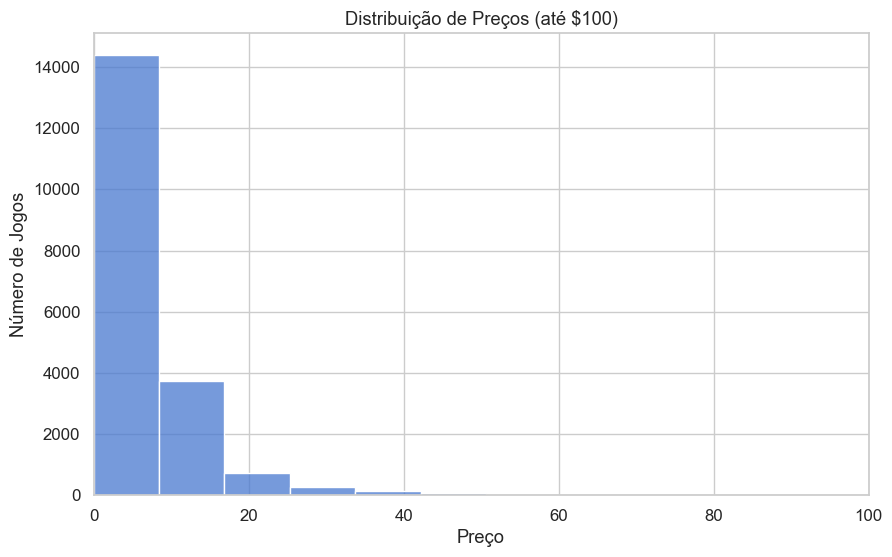

Quantidade de jogos gratuitos: 2106


In [6]:
# Jogos gratuitos
free_games = (df["price"] == 0).sum()

sns.histplot(df["price"], bins=50, kde=False)
plt.xlim(0, 100)
plt.title("Distribuição de Preços (até $100)")
plt.xlabel("Preço")
plt.ylabel("Número de Jogos")
plt.show()

print(f"Quantidade de jogos gratuitos: {free_games}")


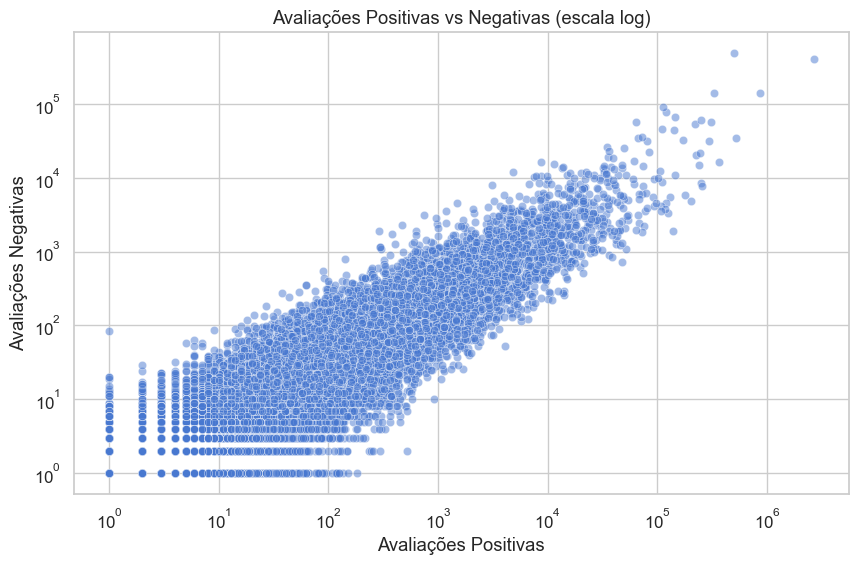

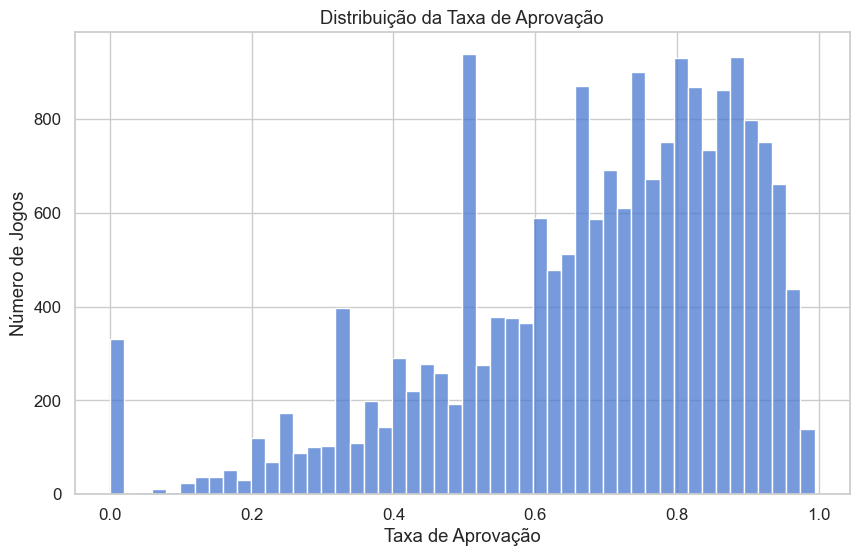

In [7]:
df["approval_rate"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"] + 1)

sns.scatterplot(data=df, x="positive_ratings", y="negative_ratings", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Avaliações Positivas vs Negativas (escala log)")
plt.xlabel("Avaliações Positivas")
plt.ylabel("Avaliações Negativas")
plt.show()

sns.histplot(df["approval_rate"], bins=50, kde=False)
plt.title("Distribuição da Taxa de Aprovação")
plt.xlabel("Taxa de Aprovação")
plt.ylabel("Número de Jogos")
plt.show()


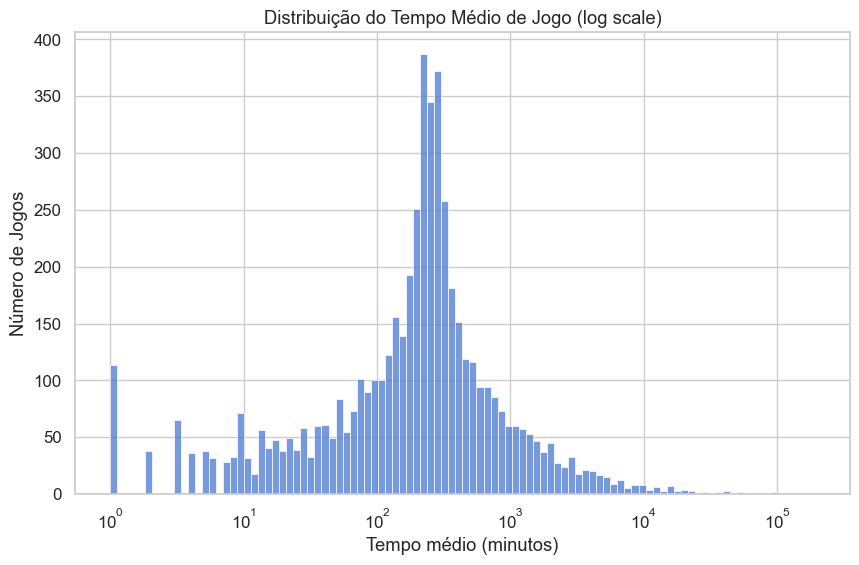

In [8]:
sns.histplot(df["average_playtime"], bins=100, log_scale=(True, False))
plt.title("Distribuição do Tempo Médio de Jogo (log scale)")
plt.xlabel("Tempo médio (minutos)")
plt.ylabel("Número de Jogos")
plt.show()


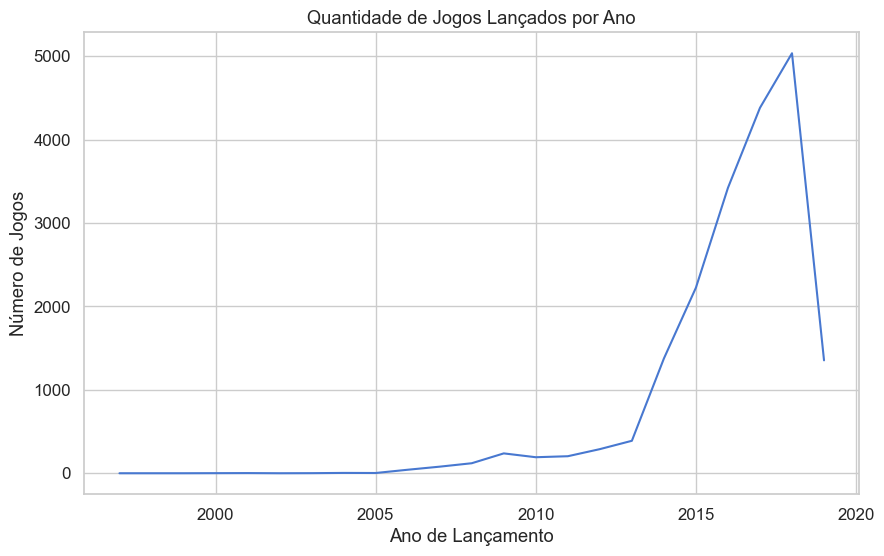

In [9]:
df["release_year"] = df["release_date"].dt.year
games_per_year = df["release_year"].value_counts().sort_index()

sns.lineplot(x=games_per_year.index, y=games_per_year.values)
plt.title("Quantidade de Jogos Lançados por Ano")
plt.xlabel("Ano de Lançamento")
plt.ylabel("Número de Jogos")
plt.show()


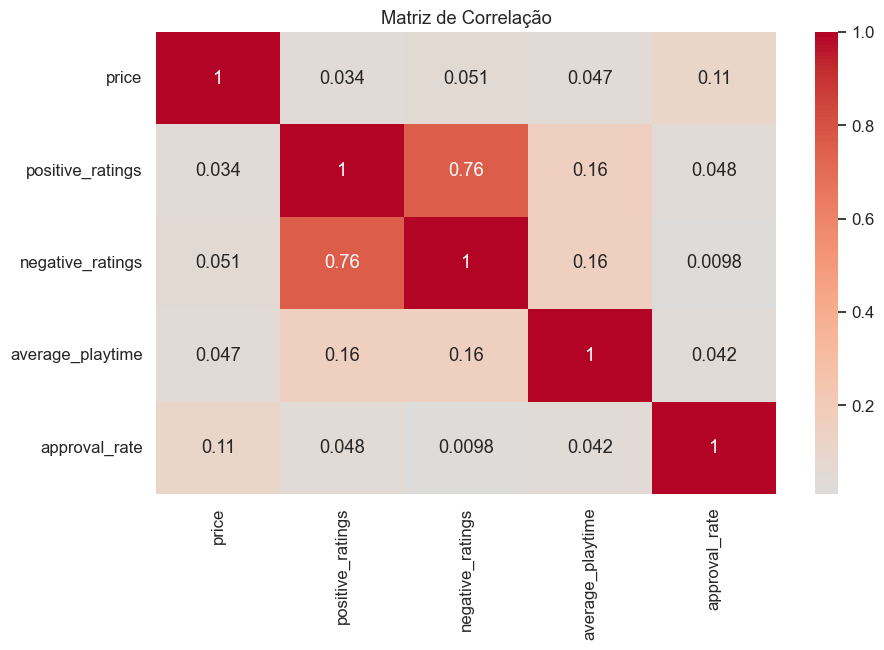

In [10]:
corr = df[["price","positive_ratings","negative_ratings","average_playtime","approval_rate"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()
